<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/02_construction_data_preparation_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# การเตรียมข้อมูลรายการจ้างก่อสร้าง ปีงบประมาณ 2569

ข้อมูล e-GP ปีงบประมาณ 2569 สะสมถึงวันที่ 30 กรกฎาคม 2569 จากไฟล์ต้นทาง 8 ไฟล์

Notebook นี้รวมไฟล์ สกัดรายการ `จ้างก่อสร้าง` และตรวจข้อมูลเบื้องต้นก่อนนำไปสำรวจต่อ


In [109]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [110]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [111]:
base_dir = Path('/content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/2569')

processed_dir = base_dir.parent / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

csv_files = sorted(base_dir.glob('*.csv'))
construction_path = processed_dir / 'construction_contracts_2569.csv'

project_dir = base_dir.parents[3]
figure_dir = project_dir / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

print(f'CSV files: {len(csv_files)}')
print(f'Output file: {construction_path}')

CSV files: 8
Output file: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv


## 1. ตรวจโครงสร้างไฟล์ต้นทาง

อ่านตัวอย่างจากไฟล์แรกเพื่อตรวจชื่อคอลัมน์และรูปแบบข้อมูล


In [112]:
sample_data = pd.read_csv(csv_files[0], nrows=5)

print(f'Sample file: {csv_files[0].name}')
print(f'Columns: {sample_data.shape[1]}')

display(sample_data)

Sample file: 2569-egp-contract-1.csv
Columns: 28


,ลำดับ,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,ชื่อประเภทโครงการ,ชื่อหน่วยงาน,ชื่อหน่วยงานย่อย,ชื่อวิธีการจัดซื้อจัดจ้าง,ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง,วันที่ประกาศจัดซื้อจัดจ้าง,วงเงินงบประมาณ (บาท),ราคากลาง (บาท),ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท),ปีงบประมาณ,วันที่เกิดรายการ,จังหวัด,เขต/อำเภอ,แขวง/ตำบล,สถานะโครงการ,พิกัดของโครงการ,ละติจูดของโครงการ,ลองจิจูดของโครงการ,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วันที่ลงนามในสัญญา,วันที่สิ้นสุดสัญญา,วงเงินงบประมาณในสัญญา (บาท),สถานะสัญญา
0,1,68099218030,ประกวดราคาเช่ารถโดยสารประจำทางปรับอากาศพลังงาน...,เช่า,องค์การขนส่งมวลชนกรุงเทพ,องค์การขนส่งมวลชนกรุงเทพ (ขสมก.) กรุงเทพฯ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,18 พ.ย. 68,15355600000,"15,326,737,242.00",14905000000,2569,29 ม.ค. 69,กรุงเทพมหานคร,พระนคร,พระบรมมหาราชวัง,ระหว่างดำเนินการ,NaN,NaN,NaN,0365529000042,บริษัท นครชัยแอร์ จำกัด,ช.16/2569,29 ม.ค. 69,29 ม.ค. 76,14905000000,ระหว่างดำเนินการ
1,2,67079254388,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างศูนย์การแ...,จ้างก่อสร้าง,กรุงเทพมหานคร,สำนักการโยธา กรุงเทพมหานคร,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,8 ก.ค. 68,4000000000,"4,000,000,000.00",3997800000,2569,7 ม.ค. 69,กรุงเทพมหานคร,ดินแดง,ดินแดง,ระหว่างดำเนินการ,POINT(100.51196175293 13.743704315315),13.74,100.51,0107537000939,บริษัท อิตาเลียนไทย ดีเวล๊อปเมนต์ จำกัด (มหาชน),กคส.สนย.๒๒-๕-๖๙,7 ม.ค. 69,26 พ.ค. 73,3997800000,ระหว่างดำเนินการ
2,3,68049277788,ประกวดราคาจ้างก่อสร้างโครงการเปลี่ยนระบบสายไฟฟ...,จ้างก่อสร้าง,การไฟฟ้านครหลวง,ฝ่ายบริหารโครงการ การไฟฟ้านครหลวง,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,15 ก.ย. 68,4083120000,"3,872,008,000.00",3870550927,2569,29 เม.ย. 69,กรุงเทพมหานคร,คลองเตย,คลองเตย,ระหว่างดำเนินการ,"POLYGON((100.64566612244 13.762437066514,100.6...",13.79,100.69,0993000532988,กิจการร่วมค้า จีบีที,MP8-3404-ABL,29 เม.ย. 69,-,3870550927,ระหว่างดำเนินการ
3,4,68099239630,ซื้อเครื่องบินลำเลียงสนับสนุนปฏิบัติการทางเรือ...,ซื้อ,กองทัพเรือ,กองทัพเรือ (สยป.ทร/งานโครงการจัดหายุทโธปกรณ์หล...,เฉพาะเจาะจง,วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,-,3770000000,"3,769,999,987.00",3769913800,2569,27 พ.ค. 69,กรุงเทพมหานคร,บางกอกใหญ่,วัดอรุณ,ระหว่างดำเนินการ,NaN,NaN,NaN,899680900xxxx,บริษัท Airbus Defence and Space S.A.U,AIR-ุ6873-01,27 พ.ค. 69,26 พ.ค. 73,3769913800,ระหว่างดำเนินการ
4,5,68109204474,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างสถาบันมะเ...,จ้างก่อสร้าง,สถาบันมะเร็งแห่งชาติ,สถาบันมะเร็งแห่งชาติ,ประกวดราคาอิเล็กทรอนิกส์ (e-bidding),วิธีการจัดหา ประกาศเชิญชวนทั่วไป คัดเลือก เฉพา...,6 ม.ค. 69,3300000000,"3,407,005,257.46",3285000000,2569,10 มิ.ย. 69,กรุงเทพมหานคร,ราชเทวี,ทุ่งพญาไท,ระหว่างดำเนินการ,"POLYGON((100.41905164719 13.570553229914,100.4...",13.57,100.42,0107547000273,บริษัท เอ็นแอล ดีเวลลอปเมนต์ จำกัด (มหาชน),192/2569 (พ),10 มิ.ย. 69,15 พ.ค. 74,3285000000,ระหว่างดำเนินการ


In [113]:
for number, column in enumerate(sample_data.columns, start=1):
    print(f'{number:02d}. {column}')

01. ลำดับ
02. รหัสโครงการ
03. ชื่อโครงการจัดซื้อจัดจ้าง
04. ชื่อประเภทโครงการ
05. ชื่อหน่วยงาน
06. ชื่อหน่วยงานย่อย
07. ชื่อวิธีการจัดซื้อจัดจ้าง
08. ชื่อกลุ่มวิธีการจัดซื้อจัดจ้าง
09. วันที่ประกาศจัดซื้อจัดจ้าง
10. วงเงินงบประมาณ (บาท)
11. ราคากลาง (บาท)
12. ราคาที่ตกลงซื้อ / จ้าง ซึ่งรวมทุกสัญญาในโครงการ (บาท)
13. ปีงบประมาณ
14. วันที่เกิดรายการ
15. จังหวัด
16. เขต/อำเภอ
17. แขวง/ตำบล
18. สถานะโครงการ
19. พิกัดของโครงการ
20. ละติจูดของโครงการ
21. ลองจิจูดของโครงการ
22. เลขประจำตัวนิติบุคคล 13 หลัก
23. ชื่อผู้ชนะการเสนอราคา
24. เลขที่สัญญา
25. วันที่ลงนามในสัญญา
26. วันที่สิ้นสุดสัญญา
27. วงเงินงบประมาณในสัญญา (บาท)
28. สถานะสัญญา


## 2. รวมไฟล์และสกัดรายการจ้างก่อสร้าง

อ่านข้อมูลทีละไฟล์ นับประเภทโครงการ และเก็บเฉพาะรายการจ้างก่อสร้าง


In [114]:
project_type_column = 'ชื่อประเภทโครงการ'

type_counts_list = []
construction_parts = []
file_summaries = []

for file_path in csv_files:
    data = pd.read_csv(file_path, low_memory=False)
    data.columns = data.columns.str.strip()

    project_type = data[project_type_column].astype('string')
    project_type = project_type.str.strip().fillna('ไม่ระบุ')

    type_counts_list.append(project_type.value_counts())

    construction = data[project_type == 'จ้างก่อสร้าง'].copy()
    construction['source_file'] = file_path.name
    construction_parts.append(construction)

    file_summaries.append({
        'file_name': file_path.name,
        'total_rows': len(data),
        'construction_rows': len(construction)
    })

    print(f'{file_path.name}: {len(data):,} rows | 'f'{len(construction):,} construction rows')

2569-egp-contract-1.csv: 514,660 rows | 136,569 construction rows
2569-egp-contract-2.csv: 504,966 rows | 30,844 construction rows
2569-egp-contract-3.csv: 502,705 rows | 7,603 construction rows
2569-egp-contract-4.csv: 502,089 rows | 3,013 construction rows
2569-egp-contract-5.csv: 501,672 rows | 1,169 construction rows
2569-egp-contract-6.csv: 501,482 rows | 585 construction rows
2569-egp-contract-7.csv: 501,038 rows | 235 construction rows
2569-egp-contract-8.csv: 436,312 rows | 61 construction rows


In [115]:
processing_summary = pd.DataFrame(file_summaries)
total_records = processing_summary['total_rows'].sum()

construction_data = pd.concat(construction_parts,ignore_index=True)

total_construction_records = len(construction_data)
construction_pct = total_construction_records / total_records * 100

print(f'Total records: {total_records:,}')
print(f'Construction records: {total_construction_records:,}')
print(f'Construction share: {construction_pct:.2f}%')

Total records: 3,964,924
Construction records: 180,079
Construction share: 4.54%


### สัดส่วนรายการตามประเภทโครงการ

เปรียบเทียบจำนวนรายการของแต่ละประเภทกับข้อมูลทั้งหมด


In [116]:
type_counts = pd.concat(type_counts_list, axis=1).fillna(0)
type_counts = type_counts.sum(axis=1).astype('int64')
type_counts = type_counts.sort_values(ascending=False)

project_type_counts = type_counts.reset_index()
project_type_counts.columns = [project_type_column, 'record_count']

project_type_counts['record_pct'] = (project_type_counts['record_count'] / total_records * 100)
display(project_type_counts)

,ชื่อประเภทโครงการ,record_count,record_pct
0,ซื้อ,2493989,62.90
1,จ้างทำของ/จ้างเหมาบริการ,1242589,31.34
2,จ้างก่อสร้าง,180079,4.54
3,เช่า,44985,1.13
4,จ้างที่ปรึกษา,1672,0.04
5,จ้างออกแบบ,1388,0.04
6,จ้างควบคุมงาน,171,0.00
7,จ้างออกแบบและควบคุมงานก่อสร้าง,35,0.00
8,-,16,0.00


In [117]:
# ดาวน์โหลดฟอนต์สำหรับแสดงภาษาไทยในกราฟ
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

fm.fontManager.addfont('thsarabunnew-webfont.ttf')
sns.set_theme(style='whitegrid', font='TH Sarabun New')
plt.rcParams['axes.unicode_minus'] = False

In [118]:
plot_data = project_type_counts.head(4).copy()
plot_data = plot_data.sort_values('record_pct')

colors = []
for project_type in plot_data[project_type_column]:
    if project_type == 'จ้างก่อสร้าง':
        colors.append('#4C6A85')
    else:
        colors.append('#A7B1BB')

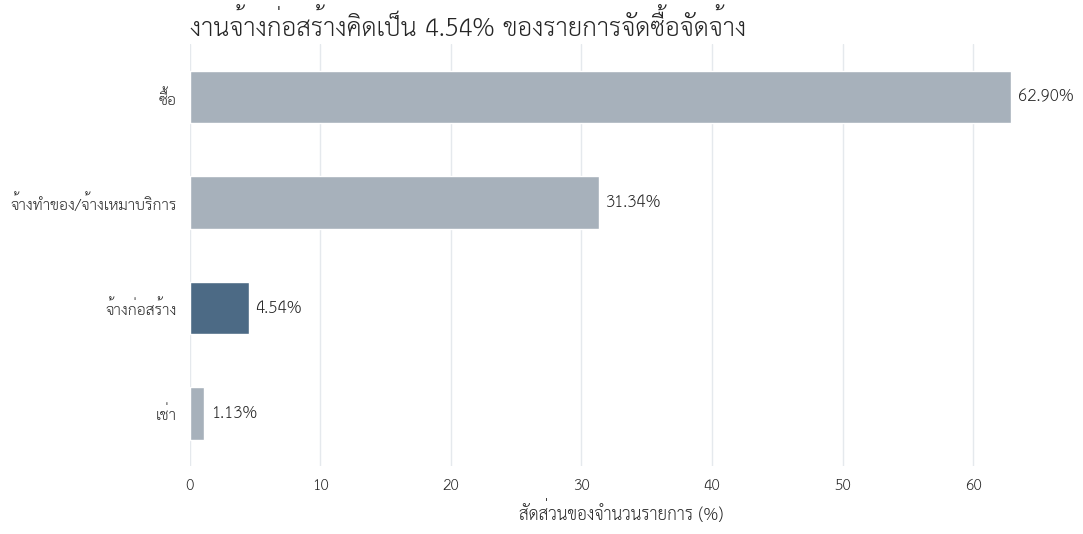

In [119]:
ax = plot_data.plot.barh(
    x=project_type_column,
    y='record_pct',
    color=colors,
    figsize=(11, 5.5),
    legend=False
)

ax.set_title(
    f'งานจ้างก่อสร้างคิดเป็น {construction_pct:.2f}% ของรายการจัดซื้อจัดจ้าง',
    loc='left',
    fontsize=18,
    fontweight='bold'
)
ax.set_xlabel('สัดส่วนของจำนวนรายการ (%)')
ax.set_ylabel('')
ax.grid(axis='x', color='#E5E9ED')
ax.grid(axis='y', visible=False)

for bar, percentage in zip(ax.patches, plot_data['record_pct']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{percentage:.2f}%',
        va='center'
    )

sns.despine(left=True, bottom=True)
fig = ax.get_figure()
fig.tight_layout()

In [120]:
png_path = figure_dir / 'fig02_01_procurement_to_construction.png'
svg_path = figure_dir / 'fig02_01_procurement_to_construction.svg'

fig.savefig(png_path, dpi=180, bbox_inches='tight')
fig.savefig(svg_path, bbox_inches='tight')

print(f'Saved: {png_path}')
print(f'Saved: {svg_path}')

Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig02_01_procurement_to_construction.png
Saved: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/figure/fig02_01_procurement_to_construction.svg


### ผลการสกัด

พบรายการจ้างก่อสร้าง 180,079 รายการ จากทั้งหมด 3,964,924 รายการ หรือ 4.54% จำนวนนี้เป็นจำนวนแถวในไฟล์ต้นทาง ยังไม่ใช่จำนวนโครงการไม่ซ้ำ


## 3. ตรวจโครงสร้างและจัดการแถวกิจการค้าร่วม

ตรวจจำนวนโครงการ สัญญา ผู้รับจ้าง และแถวที่เป็นตัวแทนกิจการค้าร่วมหรือ consortium


In [121]:
project_id_column = 'รหัสโครงการ'
contract_column = 'เลขที่สัญญา'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'

duplicate_rows = construction_data.drop(columns='source_file').duplicated().sum()

project_contract_count = construction_data[[project_id_column, contract_column]].drop_duplicates().shape[0]

data_summary = {
    'รายการจ้างก่อสร้าง': len(construction_data),
    'โครงการไม่ซ้ำ': construction_data[project_id_column].nunique(),
    'คู่โครงการ–สัญญาไม่ซ้ำ': project_contract_count,
    'ผู้รับจ้างตามรหัสไม่ซ้ำ': construction_data[supplier_id_column].nunique(),
    'รหัสโครงการที่หาย': construction_data[project_id_column].isna().sum(),
    'เลขที่สัญญาที่หาย': construction_data[contract_column].isna().sum(),
    'แถวซ้ำทุกคอลัมน์': duplicate_rows
}

display(pd.Series(data_summary, name='value').to_frame())

,value
รายการจ้างก่อสร้าง,180079
โครงการไม่ซ้ำ,178978
คู่โครงการ–สัญญาไม่ซ้ำ,179364
ผู้รับจ้างตามรหัสไม่ซ้ำ,33685
รหัสโครงการที่หาย,0
เลขที่สัญญาที่หาย,0
แถวซ้ำทุกคอลัมน์,0


In [122]:
project_row_counts = construction_data[project_id_column].value_counts()

repeated_project_count = (project_row_counts > 1).sum()
maximum_rows = project_row_counts.max()

print(f'โครงการที่มีมากกว่า 1 แถว: {repeated_project_count:,}')
print(f'จำนวนแถวสูงสุดต่อโครงการ: {maximum_rows:,}')

โครงการที่มีมากกว่า 1 แถว: 524
จำนวนแถวสูงสุดต่อโครงการ: 15


In [123]:
repeated_project_ids = project_row_counts[project_row_counts > 1].head(3).index

columns_to_show = [
    project_id_column,
    'ชื่อโครงการจัดซื้อจัดจ้าง',
    'เลขประจำตัวนิติบุคคล 13 หลัก',
    'ชื่อผู้ชนะการเสนอราคา',
    contract_column,
    'วงเงินงบประมาณในสัญญา (บาท)'
]

repeated_project_sample = construction_data[construction_data[project_id_column].isin(repeated_project_ids)]

display(repeated_project_sample[columns_to_show])

,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท)
14,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0105499000548,บริษัท มินเซนแมชีนเนอรี่ จำกัด,สญ. 41/2569,"178,540,949.00"
15,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,D888868007459,กิจการค้าร่วม กิจชัย,"สญ. 42/2569, 44/2569, 52/2569","439,680,510.00"
16,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0105555048911,บริษัทจำกัด บริษัท สุชัยธนา จำกัด(สัญญากิจการค...,"สญ. 42/2569, 44/2569, 52/2569","131,904,153.00"
17,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0103517011516,ห้างหุ้นส่วนจำกัด ห้างหุ้นส่วนจำกัด สิทธิยนต์(...,"สญ. 42/2569, 44/2569, 52/2569","307,776,357.00"
18,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0105532033721,บริษัท ล็อกซเล่ย์ พร็อพเพอร์ตี้ ดีเวลลอปเม้นท์...,สญ. 43/2569,"119,376,048.00"
19,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,D888868007461,กิจการค้าร่วมประจักษ์พีเจ,"สญ. 45/2569, 51/2569","201,372,900.00"
20,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0345561002101,บริษัทจำกัด บริษัท พีเจ โซลาร์เทค (ประเทศไทย) ...,"สญ. 45/2569, 51/2569","98,672,721.00"
21,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0343533000378,ห้างหุ้นส่วนจำกัด ห้างหุ้นส่วนจำกัด ประจักษ์พิ...,"สญ. 45/2569, 51/2569","102,700,179.00"
22,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0925563000585,บริษัท รุ่งวิจิตรการช่าง จำกัด,สญ. 46/2569,"199,676,200.00"
23,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,0105564049721,บริษัท โกลบอล วอเตอร์ ไลฟ์ จำกัด,สญ. 47/2569,"124,242,200.00"


### ตัดแถวตัวแทนกิจการค้าร่วมและแถวซ้ำ

ดำเนินการตามลำดับดังนี้:

1. ตัดแถวที่รหัสผู้รับจ้างขึ้นต้นด้วย `D`
2. จากข้อมูลที่เหลือ ตัดแถวซ้ำด้วย `รหัสโครงการ–เลขที่สัญญา–เลขประจำตัวนิติบุคคล`
3. เก็บแถวแรกของแต่ละชุด

วิธีนี้ยังเก็บหลายสัญญาภายในโครงการเดียวกัน และเก็บหลายบริษัทภายในสัญญาเดียวกัน


In [124]:
supplier_id = (
    construction_data[supplier_id_column]
    .astype('string')
    .str.strip()
)

joint_venture_mask = supplier_id.str.startswith('D', na=False)

joint_venture_rows = construction_data[joint_venture_mask].copy()

print(f'แถวกิจการค้าร่วมหรือ consortium: {len(joint_venture_rows):,}')

display(joint_venture_rows[columns_to_show].head(20))

แถวกิจการค้าร่วมหรือ consortium: 363


,รหัสโครงการ,ชื่อโครงการจัดซื้อจัดจ้าง,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,เลขที่สัญญา,วงเงินงบประมาณในสัญญา (บาท)
8,65117038133,ประกวดราคาจ้างก่อสร้างงานจ้างเหมาก่อสร้างสายเค...,D888888888001,INTERLINK CONSORTIUM,จ.ป.105/2569,"1,813,300,000.00"
15,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,D888868007459,กิจการค้าร่วม กิจชัย,"สญ. 42/2569, 44/2569, 52/2569","439,680,510.00"
19,68079483758,ประกวดราคาจ้างก่อสร้างระบบประปาบาดาล พร้อมอุปก...,D888868007461,กิจการค้าร่วมประจักษ์พีเจ,"สญ. 45/2569, 51/2569","201,372,900.00"
28,67129280905,ประกวดราคาจ้างก่อสร้างทางแนวใหม่ สาย บ.เมืองให...,D888868004228,กิจการค้าร่วม บริษัท ธาราวัญ คอนสตรัคชั่น จำกั...,สท.1/7/2569,"1,299,500,000.00"
113,68059182315,ประกวดราคาจ้างก่อสร้างและติดตั้งระบบสูบน้ำพลัง...,D888868007529,กลุ่ม Consortium S.E.G.,สบก.สจ7/69,"408,500,000.00"
162,68099167926,ประกวดราคาจ้างก่อสร้างระบบกระจายน้ำบาดาลเพื่อก...,D888868008624,กิจการค้าร่วมประจักษ์พีเจ,สญ.138/2569,"45,925,000.00"
193,68069048414,ประกวดราคาจ้างก่อสร้างพัฒนาระบบไมโครกริด ที่ อ...,D888868007768,กิจการค้าร่วม ไอทีอี-เอแอลที (ITE-ALT CONSORTIUM),C.CST.002/2569,"249,500,000.00"
199,68129397164,ประกวดราคาจ้างก่อสร้างงานก่อสร้างและเพิ่มประสิ...,D888869002715,กิจการค้าร่วม บริษัท ลาร์ซ แอนด์ ลอเร็ล จำกั...,40/2569,"248,562,100.00"
218,69029010512,ประกวดราคาจ้างก่อสร้างก่อสร้างอาคารทันตกรรมเพื...,D888869002306,กิจการค้าร่วม เอ็นพี แอนด์ วรวุฒิ,17/2569,"242,800,000.00"
225,68059551063,ประกวดราคาจ้างก่อสร้างโครงการก่อสร้างระบบระบาย...,D888868006098,กิจการค้าร่วม WV,สพน.สนน. 2/2569,"234,400,000.00"


In [125]:
construction_company_data = construction_data[~joint_venture_mask].copy()

remaining_d_rows = (
    construction_company_data[supplier_id_column]
    .astype('string')
    .str.startswith('D', na=False)
    .sum()
)

print(f'รายการก่อนตัดรหัส D: {len(construction_data):,}')
print(f'แถวรหัส D ที่ตัดออก: {len(joint_venture_rows):,}')
print(f'รายการหลังตัดรหัส D: {len(construction_company_data):,}')
print(f'รหัสขึ้นต้นด้วย D ที่ยังเหลือ: {remaining_d_rows:,}')

รายการก่อนตัดรหัส D: 180,079
แถวรหัส D ที่ตัดออก: 363
รายการหลังตัดรหัส D: 179,716
รหัสขึ้นต้นด้วย D ที่ยังเหลือ: 0


In [126]:
duplicate_key = [project_id_column, contract_column, supplier_id_column]

rows_before_drop_duplicates = len(construction_company_data)

construction_company_data = construction_company_data.drop_duplicates(subset=duplicate_key, keep='first').copy()

removed_duplicate_rows = (rows_before_drop_duplicates - len(construction_company_data))

print(f'รายการก่อน drop duplicates: {rows_before_drop_duplicates:,}')
print(f'แถวซ้ำที่ตัดออก: {removed_duplicate_rows:,}')
print(f'รายการที่เหลือ: {len(construction_company_data):,}')

รายการก่อน drop duplicates: 179,716
แถวซ้ำที่ตัดออก: 0
รายการที่เหลือ: 179,716


In [127]:
construction_company_data.to_csv(
    construction_path,
    index=False,
    encoding='utf-8-sig'
)

print(f'Saved to: {construction_path}')

Saved to: /content/drive/MyDrive/learning/dads/dads5001/project_1_dads5001/dataset/procurement/egp-contract/processed/construction_contracts_2569.csv


### ความพร้อมของฟิลด์ที่ใช้วิเคราะห์

ตรวจค่าที่หายของจังหวัด หน่วยงานย่อย ผู้รับจ้าง และวันที่เกิดรายการในระดับโครงการ


In [128]:
province_column = 'จังหวัด'
subagency_column = 'ชื่อหน่วยงานย่อย'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
transaction_date_column = 'วันที่เกิดรายการ'

quality_columns = [
    province_column,
    subagency_column,
    supplier_id_column,
    supplier_name_column,
    transaction_date_column
]

for column in quality_columns:
    construction_company_data[column] = (
        construction_company_data[column]
        .astype('string')
        .str.strip()
        .replace('', pd.NA)
    )


In [129]:
project_data = construction_company_data.drop_duplicates(subset=project_id_column, keep='first').copy()

In [130]:
province_check = construction_company_data[province_column].value_counts(dropna=False)

display(province_check.to_frame(name='record_count'))

,record_count
จังหวัด,
นครราชสีมา,8685
อุบลราชธานี,7194
ขอนแก่น,6626
เชียงใหม่,5901
อุดรธานี,5648
...,...
สิงห์บุรี,649
สมุทรสาคร,640
ระนอง,397


## ไฟล์ผลลัพธ์

ไฟล์ `construction_contracts_2569.csv` ผ่านการจัดข้อมูลสองขั้นตอน:

1. ตัดรหัสผู้รับจ้างที่ขึ้นต้นด้วย `D`
2. ตัดแถวซ้ำด้วย `รหัสโครงการ–เลขที่สัญญา–เลขประจำตัวนิติบุคคล 13 หลัก`

Notebook ถัดไปต้องใช้ `เลขประจำตัวนิติบุคคล 13 หลัก` เป็นคีย์สำหรับนับผู้รับจ้าง ไม่ใช้ `ชื่อผู้ชนะการเสนอราคา`
